# Chapter 2: Data and Sampling Distributions

## Practical Statistics for Data Scientists

Penulis:
Peter Bruce, Andrew Bruce, Peter Gedeck


## Pendahuluan

Dalam penelitian dan data science, sering kali tidak memungkinkan
untuk mengumpulkan seluruh data populasi.

Oleh karena itu, analisis dilakukan menggunakan sampel yang diambil
dari populasi.

Chapter ini membahas bagaimana sampel digunakan untuk memperkirakan
karakteristik populasi melalui konsep distribusi sampling.

Konsep yang dipelajari:

- Random sampling
- Sampling distribution
- Central Limit Theorem
- Standard error
- Bootstrap
- Confidence interval
- Distribusi probabilitas

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import warnings
warnings.filterwarnings("ignore")

# Random Sampling

Sampling adalah proses mengambil sebagian data dari populasi.

Sampel digunakan untuk memperkirakan karakteristik populasi.

Random sampling memberikan kesempatan yang sama kepada setiap anggota
populasi untuk dipilih menjadi sampel.

Contoh:
Jika terdapat jutaan nasabah bank, penelitian tidak harus mengambil
seluruh nasabah. Sebagian nasabah dapat dipilih sebagai sampel.

In [3]:
loans_income = pd.read_csv(
    "data/loans_income.csv"
)

loans_income.head()

,x
0,67000
1,52000
2,100000
3,78762
4,37041


In [4]:
len(loans_income)

50000

In [5]:
loans_income.describe()

,x
count,50000.00000
mean,68760.51844
std,32872.03537
min,4000.00000
25%,45000.00000
50%,62000.00000
75%,85000.00000
max,199000.00000


## Interpretasi

Dataset memiliki satu variabel utama yaitu pendapatan.

Data ini digunakan untuk melakukan simulasi pengambilan sampel
dan melihat bagaimana distribusi sampel dibandingkan dengan populasi.

# Population Mean dan Sample Mean

Population mean merupakan nilai rata-rata dari seluruh data populasi.

Sample mean merupakan nilai rata-rata yang diperoleh dari sebagian
data yang diambil sebagai sampel.

Sample mean digunakan untuk memperkirakan population mean.

In [6]:
population_mean = loans_income.mean()

population_mean

x    68760.51844
dtype: float64

In [7]:
sample = loans_income.sample(
    n=100,
    random_state=42
)

sample_mean = sample.mean()

sample_mean

x    66747.97
dtype: float64

## Analisis

Nilai rata-rata sampel tidak selalu sama dengan rata-rata populasi.

Perbedaan tersebut terjadi karena adanya variasi ketika proses
pengambilan sampel dilakukan.

# Sampling Distribution

Sampling distribution adalah distribusi nilai statistik yang diperoleh
dari banyak sampel berbeda yang berasal dari populasi yang sama.

Konsep ini digunakan untuk memahami variasi estimasi.

In [8]:
sample_means = []

for i in range(1000):

    sample = loans_income.sample(
        n=100
    )

    sample_means.append(
        sample.mean()
    )


sample_means = np.array(sample_means)

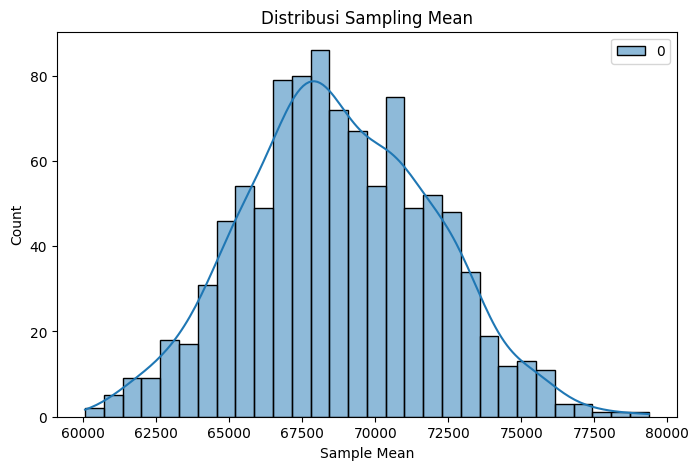

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(
    sample_means,
    bins=30,
    kde=True
)

plt.title(
    "Distribusi Sampling Mean"
)

plt.xlabel(
    "Sample Mean"
)

plt.show()

# Ukuran Sampel dan Distribusi Sampling

Semakin besar ukuran sampel, distribusi rata-rata sampel akan semakin
mendekati distribusi normal dan variasi estimasi semakin kecil.

Percobaan berikut membandingkan distribusi sampel ukuran 5 dan 20.

In [13]:
sample_mean_5 = []

for i in range(1000):
    sample = loans_income.sample(5)
    
    sample_mean_5.append(
        sample.mean().iloc[0]
    )

In [14]:
sample_mean_20 = []

for i in range(1000):
    sample = loans_income.sample(20)
    
    sample_mean_20.append(
        sample.mean().iloc[0]
    )

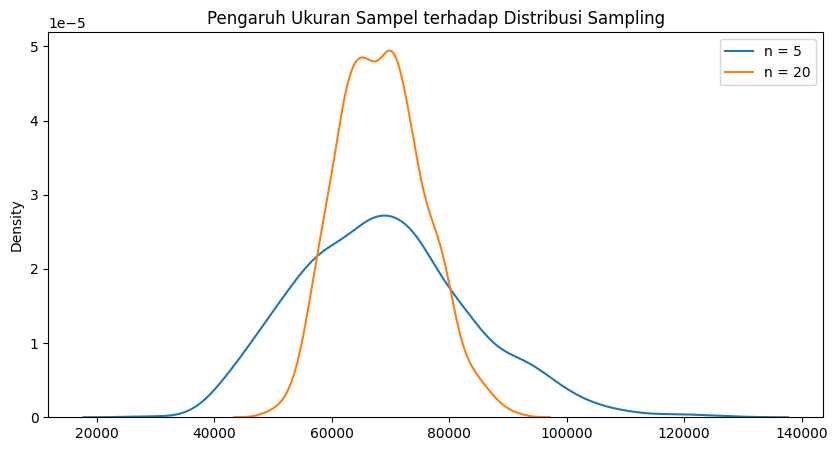

In [15]:
plt.figure(figsize=(10,5))

sns.kdeplot(
    sample_mean_5,
    label="n = 5"
)

sns.kdeplot(
    sample_mean_20,
    label="n = 20"
)


plt.legend()

plt.title(
    "Pengaruh Ukuran Sampel terhadap Distribusi Sampling"
)

plt.show()

# Central Limit Theorem (CLT)

Central Limit Theorem menyatakan bahwa distribusi rata-rata sampel
akan mendekati distribusi normal ketika jumlah sampel semakin besar.

Konsep ini menjadi dasar dalam statistik inferensial.

In [18]:
loans_income = pd.read_csv(
    "data/loans_income.csv"
).squeeze("columns")

In [19]:
type(loans_income)

pandas.core.series.Series

In [20]:
large_sample = [
    loans_income.sample(100).mean()
    for i in range(2000)
]

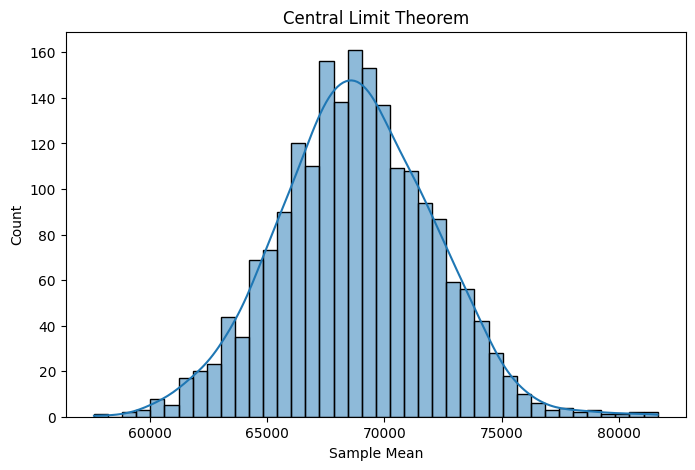

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(
    large_sample,
    bins=40,
    kde=True
)

plt.title(
    "Central Limit Theorem"
)

plt.xlabel(
    "Sample Mean"
)

plt.show()

# Standard Error

Standard error menunjukkan tingkat variasi dari estimasi statistik.

Rumus:

SE = Standard Deviation / √n

Nilai standard error akan semakin kecil ketika ukuran sampel meningkat.

In [23]:
standard_error = (
    loans_income.std()
    /
    np.sqrt(len(loans_income))
)

standard_error

147.00821129152527

# Bootstrap

Bootstrap merupakan metode resampling dengan mengambil ulang data
dari sampel yang tersedia dengan pengembalian.

Bootstrap digunakan untuk memperkirakan distribusi suatu statistik
tanpa harus mengetahui distribusi populasi sebenarnya.

In [24]:
bootstrap_mean = []

for i in range(1000):

    boot_sample = loans_income.sample(
        frac=1,
        replace=True
    )

    bootstrap_mean.append(
        boot_sample.mean()
    )


bootstrap_mean = np.array(
    bootstrap_mean
)

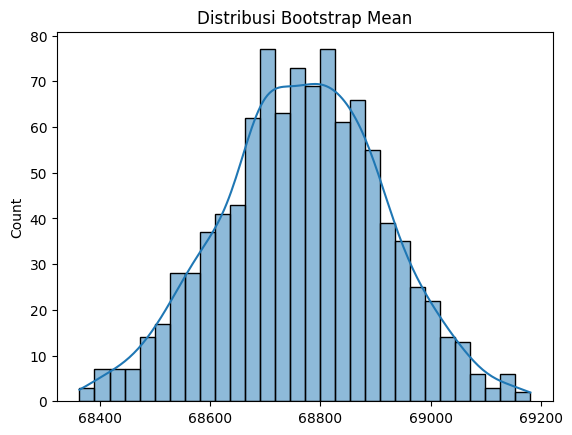

In [25]:
sns.histplot(
    bootstrap_mean,
    bins=30,
    kde=True
)

plt.title(
    "Distribusi Bootstrap Mean"
)

plt.show()

# Confidence Interval

Confidence interval merupakan rentang nilai yang digunakan untuk
memperkirakan parameter populasi.

Interval yang sering digunakan adalah 95%.

In [26]:
lower = np.percentile(
    bootstrap_mean,
    2.5
)

upper = np.percentile(
    bootstrap_mean,
    97.5
)


print(
    "95% Confidence Interval:",
    lower,
    "-",
    upper
)

95% Confidence Interval: 68473.464601 - 69056.3681


# Distribusi Normal

Distribusi normal merupakan distribusi probabilitas berbentuk lonceng.

Karakteristik:

- Simetris
- Mean dan median memiliki nilai sama
- Sebagian besar data berada di sekitar nilai tengah

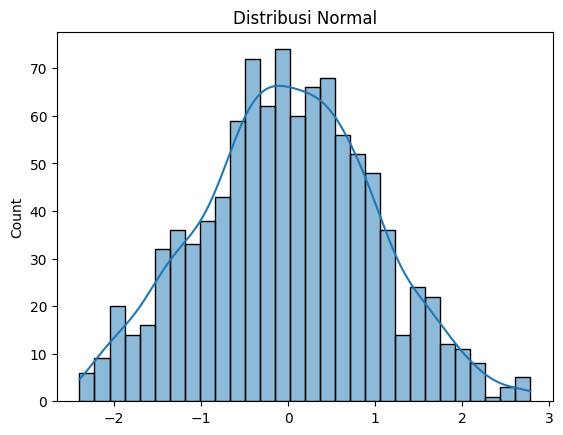

In [27]:
normal_data = np.random.normal(
    0,
    1,
    1000
)


sns.histplot(
    normal_data,
    bins=30,
    kde=True
)

plt.title(
    "Distribusi Normal"
)

plt.show()

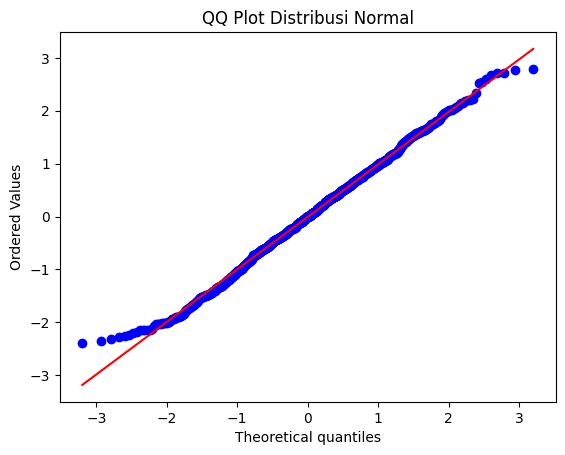

In [28]:
stats.probplot(
    normal_data,
    plot=plt
)

plt.title(
    "QQ Plot Distribusi Normal"
)

plt.show()

# Distribusi Binomial

Distribusi binomial digunakan ketika eksperimen hanya memiliki dua
kemungkinan hasil.

Contoh:

- berhasil atau gagal
- ya atau tidak
- 1 atau 0

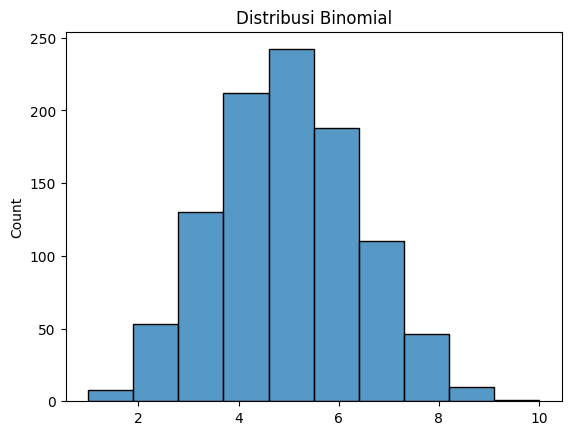

In [29]:
binomial_data = stats.binom.rvs(
    n=10,
    p=0.5,
    size=1000
)


sns.histplot(
    binomial_data,
    bins=10
)

plt.title(
    "Distribusi Binomial"
)

plt.show()

# Distribusi Poisson

Distribusi Poisson digunakan untuk menghitung jumlah kejadian dalam
suatu interval waktu tertentu.

Contoh:

- jumlah pelanggan per jam
- jumlah kecelakaan per hari

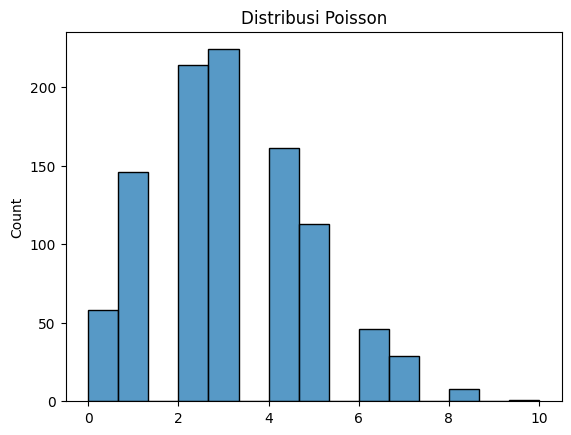

In [30]:
poisson_data = stats.poisson.rvs(
    mu=3,
    size=1000
)


sns.histplot(
    poisson_data,
    bins=15
)

plt.title(
    "Distribusi Poisson"
)

plt.show()

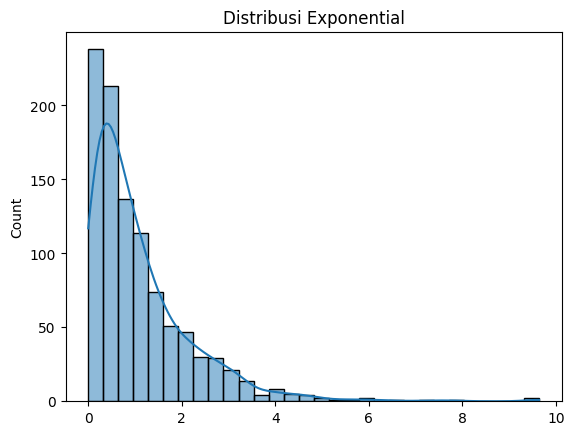

In [31]:
exp_data = stats.expon.rvs(
    scale=1,
    size=1000
)


sns.histplot(
    exp_data,
    bins=30,
    kde=True
)

plt.title(
    "Distribusi Exponential"
)

plt.show()

# Kesimpulan Chapter 2

Chapter 2 membahas hubungan antara populasi dan sampel dalam analisis
statistik.

Konsep utama:

1. Random sampling digunakan untuk mengambil sampel dari populasi.
2. Sample mean digunakan sebagai estimasi population mean.
3. Sampling distribution menjelaskan variasi estimasi.
4. Central Limit Theorem menjelaskan pembentukan distribusi normal.
5. Bootstrap digunakan untuk memperkirakan distribusi statistik.
6. Confidence interval digunakan untuk mengukur ketidakpastian.
7. Distribusi probabilitas membantu memahami pola data.

Pemahaman konsep sampling menjadi dasar sebelum melakukan analisis
statistik dan pembangunan model machine learning.